In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import pickle
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../dataset/data_cuaca.csv')
print("Shape:", df.shape)
print(df.head())

Shape: (731, 9)
      tanggal  suhu_max  suhu_min  suhu_rata  curah_hujan  kecepatan_angin  \
0  2023-01-01      29.8      23.0       25.6          3.6             12.9   
1  2023-01-02      28.6      23.2       25.6         11.1             16.1   
2  2023-01-03      29.8      23.7       26.6          1.3             18.8   
3  2023-01-04      29.2      23.3       26.1          2.6             23.6   
4  2023-01-05      28.9      23.0       26.1          5.1             22.9   

   kelembaban_max  kelembaban_min  kondisi  
0              95              68  Berawan  
1              94              74    Hujan  
2              89              66  Berawan  
3              91              74  Berawan  
4              93              75  Berawan  


In [2]:
print("=== INFO DATASET ===")
print(df.info())

print("\n=== STATISTIK DESKRIPTIF ===")
print(df.describe())

print("\n=== MISSING VALUES ===")
print(df.isnull().sum())

print("\n=== DISTRIBUSI LABEL ===")
print(df['kondisi'].value_counts())

=== INFO DATASET ===
<class 'pandas.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   tanggal          731 non-null    str    
 1   suhu_max         731 non-null    float64
 2   suhu_min         731 non-null    float64
 3   suhu_rata        731 non-null    float64
 4   curah_hujan      731 non-null    float64
 5   kecepatan_angin  731 non-null    float64
 6   kelembaban_max   731 non-null    int64  
 7   kelembaban_min   731 non-null    int64  
 8   kondisi          731 non-null    str    
dtypes: float64(5), int64(2), str(2)
memory usage: 63.2 KB
None

=== STATISTIK DESKRIPTIF ===
         suhu_max    suhu_min   suhu_rata  curah_hujan  kecepatan_angin  \
count  731.000000  731.000000  731.000000   731.000000       731.000000   
mean    30.740903   23.043639   26.125992     5.963885        11.738167   
std      1.446037    1.246451    0.887606     8.659933       

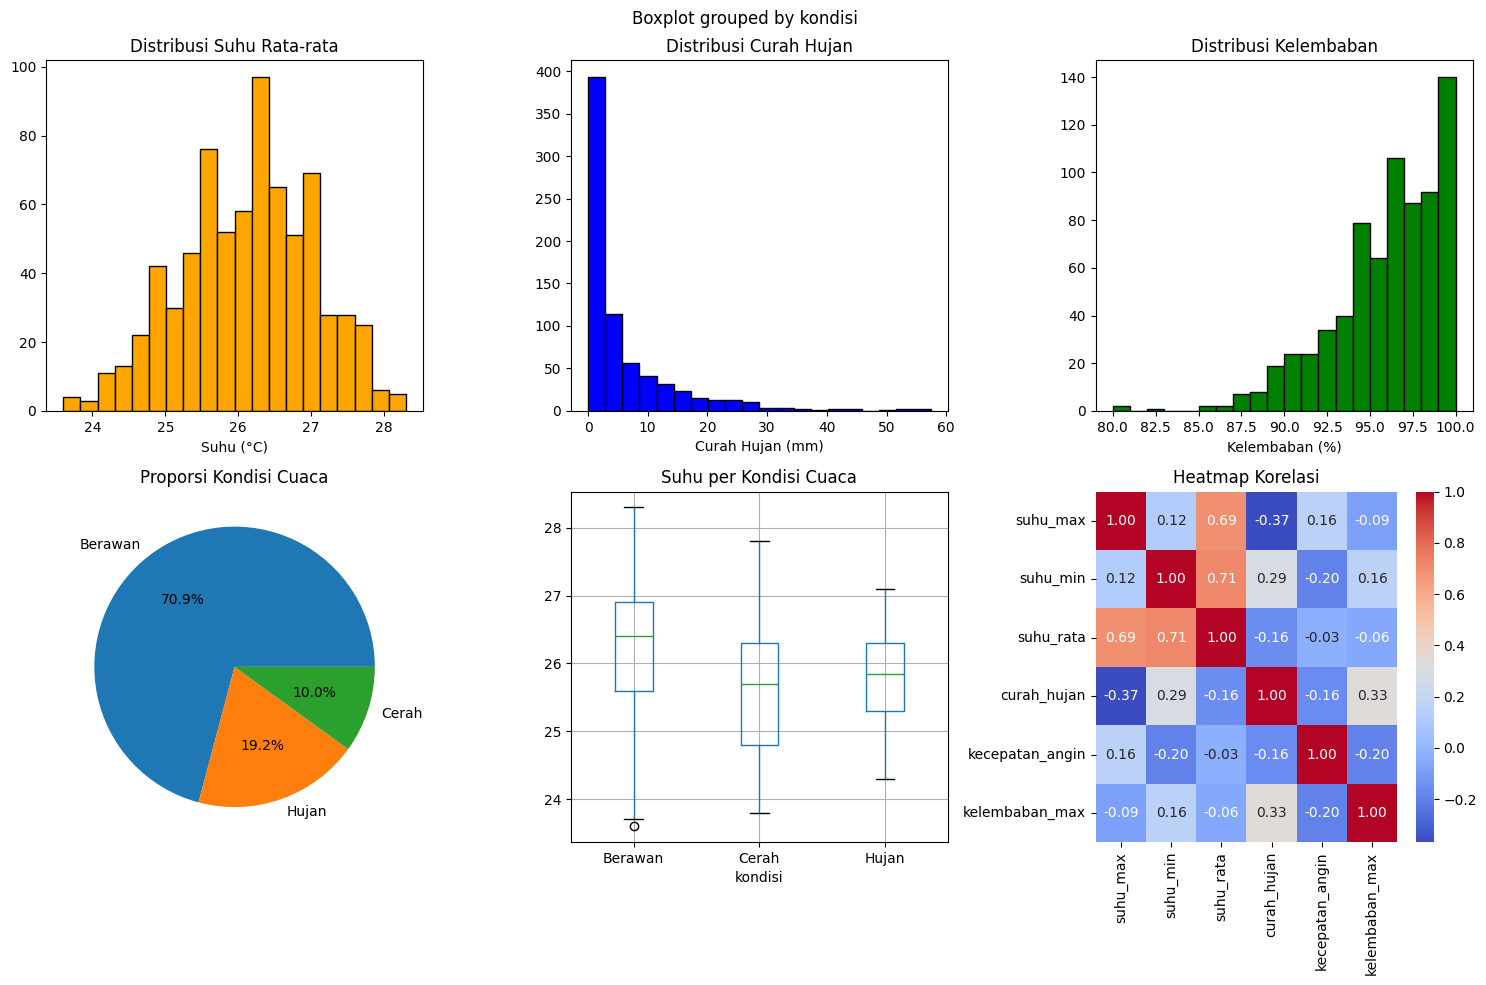

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Distribusi suhu
axes[0,0].hist(df['suhu_rata'], bins=20, color='orange', edgecolor='black')
axes[0,0].set_title('Distribusi Suhu Rata-rata')
axes[0,0].set_xlabel('Suhu (°C)')

# Distribusi curah hujan
axes[0,1].hist(df['curah_hujan'], bins=20, color='blue', edgecolor='black')
axes[0,1].set_title('Distribusi Curah Hujan')
axes[0,1].set_xlabel('Curah Hujan (mm)')

# Distribusi kelembaban
axes[0,2].hist(df['kelembaban_max'], bins=20, color='green', edgecolor='black')
axes[0,2].set_title('Distribusi Kelembaban')
axes[0,2].set_xlabel('Kelembaban (%)')

# Pie chart kondisi cuaca
kondisi_count = df['kondisi'].value_counts()
axes[1,0].pie(kondisi_count, labels=kondisi_count.index, autopct='%1.1f%%')
axes[1,0].set_title('Proporsi Kondisi Cuaca')

# Boxplot suhu per kondisi
df.boxplot(column='suhu_rata', by='kondisi', ax=axes[1,1])
axes[1,1].set_title('Suhu per Kondisi Cuaca')

# Heatmap korelasi
corr_cols = ['suhu_max','suhu_min','suhu_rata','curah_hujan','kecepatan_angin','kelembaban_max']
sns.heatmap(df[corr_cols].corr(), annot=True, fmt='.2f', ax=axes[1,2], cmap='coolwarm')
axes[1,2].set_title('Heatmap Korelasi')

plt.tight_layout()
plt.savefig('visualisasi_data.png', dpi=150)
plt.show()